# sktime / skbase adapters: bootstraps as estimator classes

Every method in `tsbootstrap` is reachable two ways. The quickstart used the
functional core: one `bootstrap()` call configured with a typed spec. This
notebook uses the object-oriented surface. Under `tsbootstrap.adapters` each
method is also a `skbase.BaseObject` estimator class with a scikit-learn style
constructor and a `.bootstrap(...)` generator.

Both surfaces exist for different reasons. The functional core stays stateless
and easy to accelerate. The adapter classes carry parameters, support
`get_params` / `set_params` / `clone`, and expose sktime tags, so they drop into
sktime pipelines and the skbase object registry. The algorithms are the same;
the two surfaces differ only in how you reach them. What follows lists the adapter
classes, runs a few on the bundled airline dataset, shows the `return_indices`
behavior, reads the sktime tags, and checks the skbase object contract.

In [1]:
# On Colab or Binder, install tsbootstrap first (skipped if already present):
try:
    import tsbootstrap  # noqa: F401
except ImportError:
    %pip install -q "tsbootstrap[examples]"

## The adapter classes

The adapters live in `tsbootstrap.adapters`. Each one wraps a method from the
functional core as a thin estimator. Here is the full set that ships, read off
the package, with the sktime tags each carries.

In [2]:
import pandas as pd

import tsbootstrap.adapters as adapters

rows = []
for name in adapters.__all__:
    if name == "BaseTimeSeriesBootstrap":
        continue  # the shared base, not a concrete method
    cls = getattr(adapters, name)
    tags = cls.get_class_tags()
    rows.append(
        {
            "adapter": name,
            "bootstrap_type": tags["bootstrap_type"],
            "multivariate": tags["capability:multivariate"],
        }
    )

adapter_table = pd.DataFrame(rows).set_index("adapter")
adapter_table

,bootstrap_type,multivariate
adapter,,
IIDBootstrap,iid,True
MovingBlockBootstrap,block,True
CircularBlockBootstrap,block,True
StationaryBlockBootstrap,block,True
NonOverlappingBlockBootstrap,block,True
TaperedBlockBootstrap,block,True
ARResidualBootstrap,model,False
ARIMAResidualBootstrap,model,False
VARResidualBootstrap,model,True


The columns mirror the functional taxonomy: `iid` resampling, `block` methods
(moving, circular, stationary, non-overlapping, tapered), and `model` based
bootstraps (AR, ARIMA, VAR residual, and the sieve). `BaseTimeSeriesBootstrap`
is the shared base that holds the delegation logic; it is not a method you
instantiate directly.

## The data: airline passengers

We use the classic monthly airline passenger counts bundled with sktime. It is
small (144 points), real, and has both trend and seasonality, so the different
bootstrap families behave visibly differently on it.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sktime.datasets import load_airline

y = load_airline()
print("type:", type(y).__name__, " length:", len(y))
y_values = y.to_numpy(dtype=float)
y_values[:6]

type: Series  length: 144


array([112., 118., 132., 129., 121., 135.])

## Constructing an estimator and running its generator

The constructor takes the method's parameters plus `n_bootstraps` and
`random_state`, scikit-learn style. Calling `.bootstrap(X)` returns a generator
that yields `n_bootstraps` replicate series. We pass the raw NumPy values; each
yielded replicate is a NumPy array the same length as the input.

In [4]:
from tsbootstrap.adapters import MovingBlockBootstrap

mbb = MovingBlockBootstrap(block_length=12, n_bootstraps=200, random_state=0)
print("get_params:", mbb.get_params())
print("get_n_bootstraps:", mbb.get_n_bootstraps())

gen = mbb.bootstrap(y_values)  # a generator, nothing computed yet
import types

print("is a generator:", isinstance(gen, types.GeneratorType))

replicates = list(gen)  # draining the generator does the work
print("collected:", len(replicates), "replicates, each shape", replicates[0].shape)

get_params: {'block_length': 12, 'n_bootstraps': 200, 'random_state': 0}
get_n_bootstraps: 200
is a generator: True


collected: 200 replicates, each shape (144,)


## Three adapters end to end

We run three different families on the airline series and overlay eight
replicates from each on a single plot: the moving block (keeps local seasonal
runs), the i.i.d. baseline (shuffles all structure away), and the AR residual
bootstrap (resamples innovations around a fitted AR model). Each family gets its
own colour and linestyle so they stay distinguishable in grayscale. The
differences between them are why you would pick one method over another.

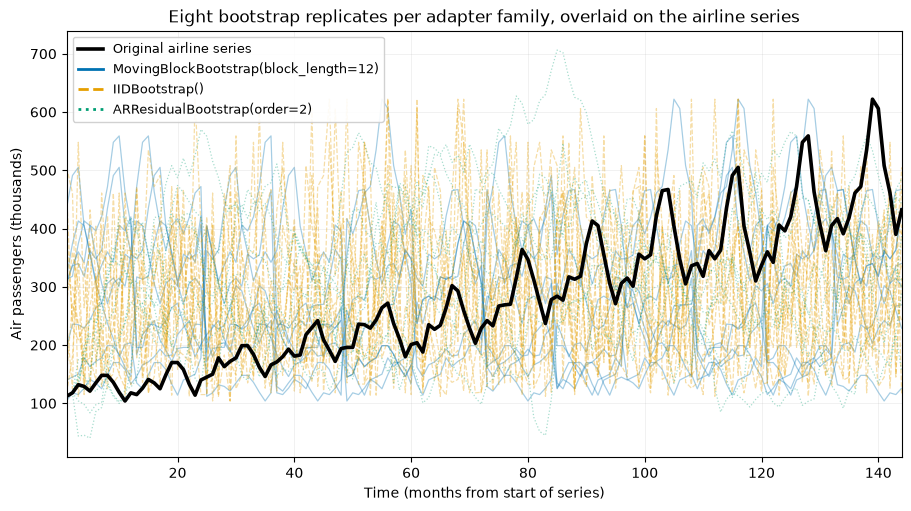

In [5]:
from tsbootstrap.adapters import ARResidualBootstrap, IIDBootstrap

estimators = {
    "MovingBlockBootstrap(block_length=12)": MovingBlockBootstrap(
        block_length=12, n_bootstraps=50, random_state=0
    ),
    "IIDBootstrap()": IIDBootstrap(n_bootstraps=50, random_state=0),
    "ARResidualBootstrap(order=2)": ARResidualBootstrap(order=2, n_bootstraps=50, random_state=0),
}

# Colorblind-safe palette (Wong 2011); each adapter also gets a distinct
# linestyle so the families stay distinguishable in grayscale or for readers
# with colour-vision deficiency.
styles = {
    "MovingBlockBootstrap(block_length=12)": ("#0072B2", "-"),  # blue, solid
    "IIDBootstrap()": ("#E69F00", "--"),  # orange, dashed
    "ARResidualBootstrap(order=2)": ("#009E73", ":"),  # green, dotted
}

months = np.arange(1, len(y_values) + 1)

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")

# Faint replicate clouds, eight per adapter, coloured + styled per family.
for label, est in estimators.items():
    color, ls = styles[label]
    for i, rep in enumerate(est.bootstrap(y_values)):
        if i >= 8:
            break
        ax.plot(months, rep, color=color, linestyle=ls, alpha=0.35, lw=0.9, zorder=1)

# Original series emphasized on top, in front of every replicate.
ax.plot(months, y_values, color="black", lw=2.6, zorder=3, label="Original airline series")

# One bold proxy line per adapter for a readable legend (the faint replicates
# would otherwise make the legend swatches nearly invisible).
from matplotlib.lines import Line2D

legend_handles = [Line2D([0], [0], color="black", lw=2.6, label="Original airline series")]
legend_handles += [
    Line2D([0], [0], color=styles[label][0], linestyle=styles[label][1], lw=2.0, label=label)
    for label in estimators
]

ax.set_title("Eight bootstrap replicates per adapter family, overlaid on the airline series")
ax.set_xlabel("Time (months from start of series)")
ax.set_ylabel("Air passengers (thousands)")
ax.set_xlim(months[0], months[-1])
ax.legend(handles=legend_handles, loc="upper left", framealpha=0.9, fontsize=9)
ax.grid(True, alpha=0.25, linewidth=0.5)
plt.show()

The moving block replicates (blue, solid) preserve stretches of the original
seasonal shape, just reshuffled in time. The IID replicates (orange, dashed)
lose that ordering, so the trend and seasonality collapse into noise around the
level. The AR residual replicates (green, dotted) keep a smooth autoregressive
character because they rebuild each series from a fitted model and resampled
innovations. The overlay shows how much each method's assumptions change what a
replicate looks like.

## `return_indices`: where each value came from

By default the generator yields just the replicate series. Pass
`return_indices=True` and it yields `(sample, indices)` pairs instead, where
`indices` are the positions in the original series that were drawn (or `None` for
methods that do not resample observations). This is what you need to align a
resampled target with resampled exogenous features, or to inspect coverage.

In [6]:
mbb_small = MovingBlockBootstrap(block_length=12, n_bootstraps=3, random_state=0)

for k, (sample, indices) in enumerate(mbb_small.bootstrap(y_values, return_indices=True)):
    print(
        f"replicate {k}: sample shape {sample.shape}, "
        f"indices shape {None if indices is None else indices.shape}, "
        f"first indices {None if indices is None else indices[:8]}"
    )

replicate 0: sample shape (144,), indices shape (144,), first indices [106 107 108 109 110 111 112 113]
replicate 1: sample shape (144,), indices shape (144,), first indices [88 89 90 91 92 93 94 95]
replicate 2: sample shape (144,), indices shape (144,), first indices [87 88 89 90 91 92 93 94]


The indices are monotone within each 12-long block (a contiguous slice of the
original months) and jump between blocks, which is exactly the moving-block
construction. The values in each replicate are `y_values[indices]`, so you can
reconstruct the sample from the original series and the indices alone.

## sktime tags

Because the adapters are skbase objects, they advertise capabilities through
tags that sktime and the skbase registry read. The most useful here is
`capability:multivariate`: block and i.i.d. methods accept multivariate input,
while the univariate model-based ones (AR, ARIMA, sieve) do not.

In [7]:
tag_rows = []
for name in adapters.__all__:
    if name == "BaseTimeSeriesBootstrap":
        continue
    cls = getattr(adapters, name)
    tag_rows.append({"adapter": name, **cls.get_class_tags()})

tags_table = pd.DataFrame(tag_rows).set_index("adapter")
tags_table

,object_type,bootstrap_type,capability:multivariate
adapter,,,
IIDBootstrap,bootstrap,iid,True
MovingBlockBootstrap,bootstrap,block,True
CircularBlockBootstrap,bootstrap,block,True
StationaryBlockBootstrap,bootstrap,block,True
NonOverlappingBlockBootstrap,bootstrap,block,True
TaperedBlockBootstrap,bootstrap,block,True
ARResidualBootstrap,bootstrap,model,False
ARIMAResidualBootstrap,bootstrap,model,False
VARResidualBootstrap,bootstrap,model,True


## The skbase object contract

The adapters follow the standard skbase estimator contract, which is what lets
them live in sktime pipelines: parameters are introspectable, the object clones
faithfully from its own params, and each class ships `get_test_params()` for the
automated estimator checks. We exercise that contract directly here.

A note on `check_estimator`: the bundled `skbase` version in `tsbootstrap[examples]`
does not expose a standalone `check_estimator` function (it lives behind the
`QuickTester` mixin / sktime's own suite, whose API drifts across versions), so
rather than pin to a flaky import we verify the same contract by hand. It runs in
well under a second.

In [8]:
from skbase.base import BaseObject

est = MovingBlockBootstrap(block_length=10, n_bootstraps=20, random_state=42)

# 1. it really is a skbase object
assert isinstance(est, BaseObject)

# 2. params round-trip: cloning from get_params reproduces the configuration
clone = type(est)(**est.get_params())
assert clone.get_params() == est.get_params()

# 3. get_test_params yields constructible, runnable configurations
for params in MovingBlockBootstrap.get_test_params():
    inst = MovingBlockBootstrap(**params)
    reps = list(inst.bootstrap(y_values))
    assert len(reps) == inst.get_n_bootstraps()
    print(f"test config {params} -> {len(reps)} replicates")

print("\nskbase object contract: params round-trip, clone, and test configs all pass.")

test config {'block_length': 5, 'n_bootstraps': 10} -> 10 replicates
test config {'block_length': 'auto', 'n_bootstraps': 5} -> 5 replicates

skbase object contract: params round-trip, clone, and test configs all pass.


## When to reach for the adapters

Use the functional `bootstrap()` core when you want a stateless call and the
lowest overhead. Reach for these adapter classes when you want the sktime
ecosystem: estimator objects you can clone and tune, tags that describe their
capabilities, and a generator interface that fits alongside sktime forecasters
and pipelines. The underlying algorithms are the same either way.